In [1]:
import pandas as pd

df = pd.read_csv(r"D:\customer-intelligence-platform\Dataset\online_retail.csv")


In [4]:

df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
df = df.dropna(subset=["CustomerID"])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      406829 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.9+ MB


In [8]:
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"])

In [9]:
df["InvoiceDate"].dtype

dtype('<M8[ns]')

In [10]:
df=df[(df["Quantity"]>0)&(df["UnitPrice"]>0)]

In [11]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,397884.000000,397884,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023360,3.116488,15294.423453
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,179.331775,NaN,22.097877,1713.141560


In [12]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]


In [13]:
df[["Quantity", "UnitPrice", "TotalAmount"]].head()


,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
 8   TotalAmount  397884 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


In [15]:
df.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64

RFM is a customer segmentation technique based on Recency, Frequency, and Monetary value.
It helps identify high-value, loyal, and at-risk customers using transactional data and is often used as a baseline before clustering or churn modeling.

In [16]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
}).reset_index()

rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]


In [20]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    4,
    labels=[4,3,2,1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1,2,3,4]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    4,
    labels=[1,2,3,4]
)


In [23]:
rfm[["R_Score", "F_Score", "M_Score"]].isna().sum()
#verifying it worked or not

R_Score    0
F_Score    0
M_Score    0
dtype: int64

In [21]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

In [24]:
def segment_customer(score):
    if score >= "444":
        return "Champions"
    elif score >= "344":
        return "Loyal Customers"
    elif score >= "244":
        return "Potential Loyalist"
    elif score >= "144":
        return "At Risk"
    else:
        return "Lost"

rfm["Segment"] = rfm["RFM_Score"].apply(segment_customer)


In [25]:
rfm["Segment"].value_counts()


Segment
Lost                  1074
At Risk                995
Potential Loyalist     962
Loyal Customers        829
Champions              478
Name: count, dtype: int64

In [28]:
rfm.to_csv(r"D:\customer-intelligence-platform\data\processed\rfm_segments.csv", index=False)


Define CHURN

Customer is churned if no purchase in last 90 days

In [29]:
churn_threshold = 90  # days

rfm["Churn"] = rfm["Recency"].apply(
    lambda x: 1 if x > churn_threshold else 0
)


In [30]:
rfm["Churn"].value_counts(normalize=True)

Churn
0    0.665975
1    0.334025
Name: proportion, dtype: float64

Prepare Features for Model

In [33]:
X = rfm[[ "Frequency", "Monetary"]]
y = rfm["Churn"]

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       0.80      0.81      0.80       578
           1       0.61      0.59      0.60       290

    accuracy                           0.74       868
   macro avg       0.70      0.70      0.70       868
weighted avg       0.73      0.74      0.74       868

ROC-AUC: 0.7847094618780575


Add RFM Segment as Feature

In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
rfm["Segment_encoded"] = le.fit_transform(rfm["Segment"])

X = rfm[["Frequency", "Monetary", "Segment_encoded"]]
y = rfm["Churn"]


In [36]:
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       0.90      0.98      0.94       578
           1       0.96      0.77      0.85       290

    accuracy                           0.91       868
   macro avg       0.93      0.88      0.90       868
weighted avg       0.92      0.91      0.91       868

ROC-AUC: 0.9731267151891182


Model Explainability (Feature Importance + SHAP)

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance


Segment_encoded    0.704314
Monetary           0.157525
Frequency          0.138161
dtype: float64

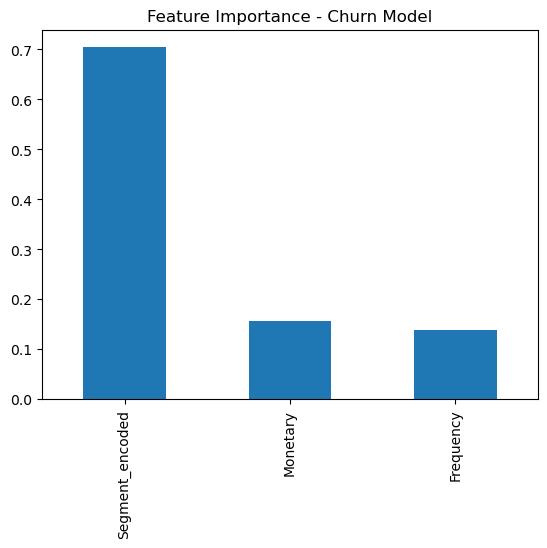

In [38]:
importance.plot(kind="bar")
plt.title("Feature Importance - Churn Model")
plt.show()


In [49]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(rf, "models/churn_model.pkl")
joblib.dump(le, "models/segment_encoder.pkl")



['models/segment_encoder.pkl']

In [6]:
import os
import joblib

# Get project root (one level up from notebooks/)
BASE_DIR = os.path.dirname(os.getcwd())

rf = joblib.load(os.path.join(BASE_DIR, "models", "churn_model.pkl"))
print("Model loaded successfully")


Model loaded successfully


In [7]:
print(type(rf))


<class 'sklearn.ensemble._forest.RandomForestClassifier'>
